# Part 1: Hierarchical Clustering & Portfolio Construction
## 1. Data Loading

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch

plt.style.use('seaborn-v0_8-whitegrid')


df = pd.read_csv('raw_dataset.csv', index_col='ticker')

print(f"Number of assets: {df.shape[0]}")
display(df.head())


Number of assets: 1212


,volatility,momentum_12_1,max_drawdown,skewness,kurtosis,pe_ratio,roe,market_cap,beta
ticker,,,,,,,,,
A,0.293022,-0.035362,-0.360411,0.031739,2.847104,26.892778,0.206190,34842013696,1.298
AAPL,0.267779,0.189756,-0.296203,0.022923,2.482728,33.448800,1.520210,3888777003008,1.107
ABBV,0.226676,0.173003,-0.219154,-1.733872,14.289002,95.258480,11.066669,397325729792,0.334
ABNB,0.451888,-0.055079,-0.534007,-0.524063,3.349974,31.734490,0.302330,76671844352,1.139
ABT,0.213455,0.080596,-0.247474,0.084297,2.954092,30.083109,0.131580,195296903168,0.751


The dataset contains the initial universe of 1212 assets. Each ticker is associated with specific financial indicators that will serve as the basis for our multi-dimensional clustering.

## 2. Data Preprocessing and Initial Dendrogram

To ensure a high-quality clustering process, we perform two preprocessing steps:
1. **Outlier Clipping:** Financial ratios often contain extreme values that can distort the clusters. We clip the top and bottom 1% of the data for highly skewed variables.
2. **Standardization:** Since metrics like P/E Ratio and Market Cap have different scales, we apply a `StandardScaler` to ensure each feature contributes equally to the distance calculation.

We then perform Hierarchical Agglomerative Clustering using the Ward variance minimization algorithm. This method focuses on minimizing the within-cluster variance, resulting in compact and distinct groups.

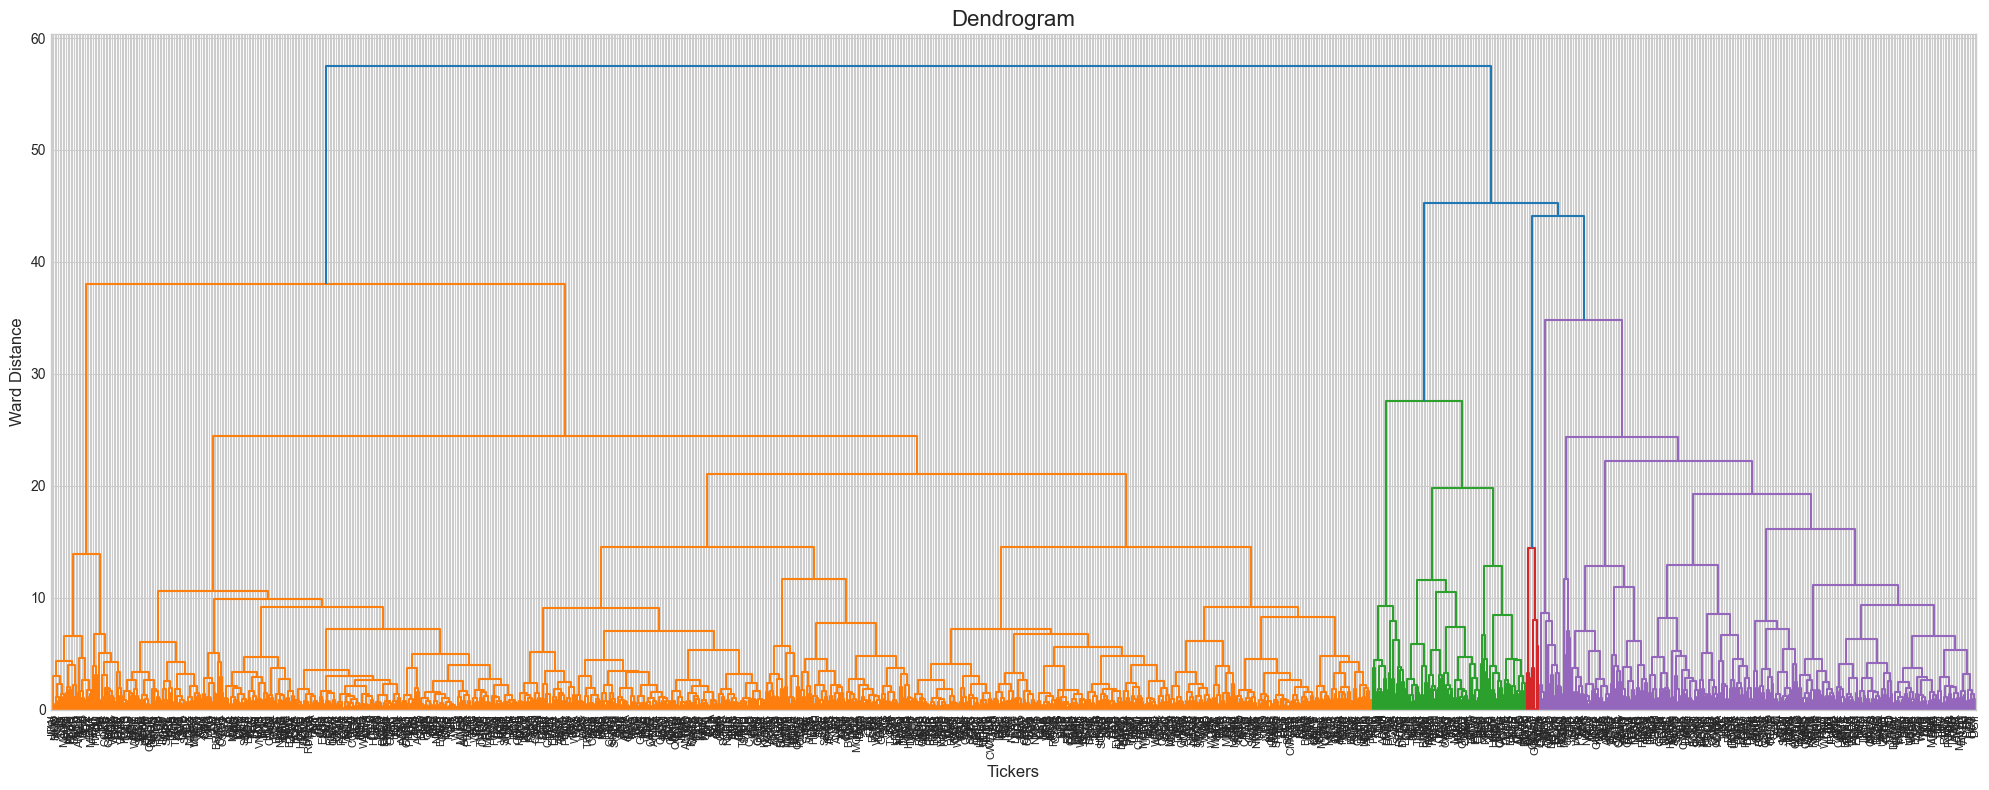

In [12]:
df_clean = df.copy() 

# Outlier Clipping
features_to_clip = ['pe_ratio', 'roe', 'skewness', 'kurtosis']

for col in features_to_clip:
    lower_bound = df_clean[col].quantile(0.01)
    upper_bound = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

# Data standardization
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns, index=df_clean.index)


# Dendrogram
Z = sch.linkage(df_scaled, method='ward')

plt.figure(figsize=(20, 8))
plt.title("Dendrogram", fontsize=16)
dendrogram = sch.dendrogram(
    Z, 
    labels=df_scaled.index, 
    leaf_rotation=90, 
    leaf_font_size=8
)
plt.xlabel("Tickers", fontsize=12)
plt.ylabel("Ward Distance", fontsize=12)
plt.tight_layout()

 The dendrogram above visualizes the hierarchical relationships between stocks. The vertical axis represents the Ward Distance, the higher the horizontal link, the more dissimilar the clusters being joined. This graph provides the first glimpse into the natural groupings of our universe based on fundamental risk and valuation metrics.

## 3. Determining the Optimal Number of Clusters

To move from a Dendrogram to a practical classification, we need to determine the optimal number of clusters. We use the **Silhouette Score**, which measures how similar an object is to its own cluster compared to other clusters.

A higher Silhouette Score indicates that the clusters are well-defined and distinct. We test a range of $k$ from 2 to 10 to find the best number for our fundamental analysis.

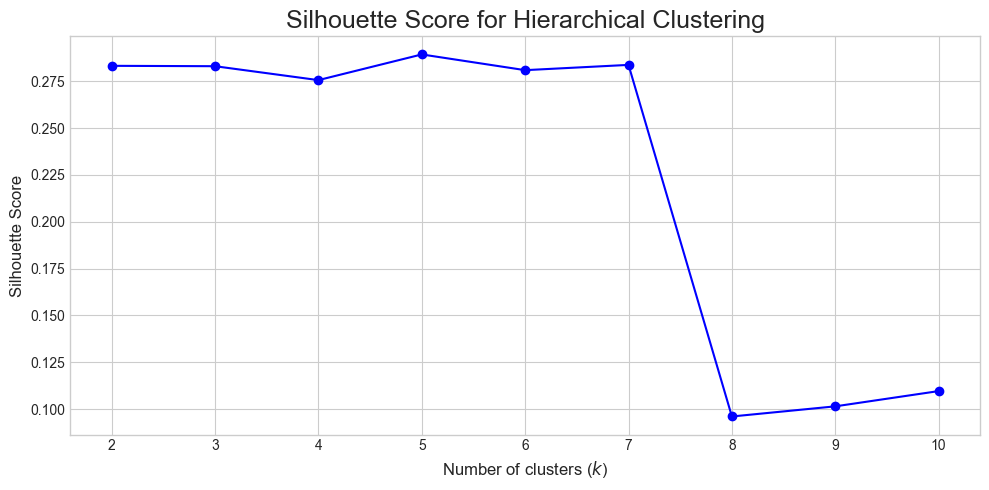

The optimal number of clusters according to the Silhouette Score is: 5


In [13]:
from sklearn.metrics import silhouette_score

range_n_clusters = range(2, 11)
silhouette_scores = []

for num_clusters in range_n_clusters:
    cluster_labels = sch.fcluster(Z, num_clusters, criterion='maxclust')
    score = silhouette_score(df_scaled, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='-', color='b')
plt.title("Silhouette Score for Hierarchical Clustering", fontsize=18)
plt.xlabel("Number of clusters ($k$)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.xticks(range_n_clusters)
plt.grid(True)
plt.tight_layout()
plt.show()

best_k = range_n_clusters[np.argmax(silhouette_scores)]
print(f"The optimal number of clusters according to the Silhouette Score is: {best_k}")

## 4. Cluster Profiling and Tactical Selection

With $k=5$ established as the optimal number of clusters, we now project the categorical labels onto our original dataset. This allows us to calculate the centroid of each group across all financial metrics. 

By analyzing these profiles, we can identify which clusters align with our mandate to improve yield while limiting volatility. We look specifically for:
* **Defensive Stability:** Low volatility and consistent Beta.
* **Profitability:** High ROE.
* **Momentum & Quality:** Positive price trends and healthy P/E ratios.

In [14]:
optimal_k = 5

# Assigning the 5 clusters to the assets
df_clean['Cluster_HC'] = sch.fcluster(Z, optimal_k, criterion='maxclust')

# Computing the mean of each metric per cluster
cluster_profiles_optimal = df_clean.groupby('Cluster_HC').mean()

print(f"Average profile of the {optimal_k} clusters ")
display(cluster_profiles_optimal.round(2))

print("\n Breakdown of assets per cluster")
display(df_clean['Cluster_HC'].value_counts().sort_index())

Average profile of the 5 clusters 


,volatility,momentum_12_1,max_drawdown,skewness,kurtosis,pe_ratio,roe,market_cap,beta
Cluster_HC,,,,,,,,,
1,0.29,0.22,-0.30,-0.07,6.14,27.06,1.17,9.300055e+10,0.91
2,0.30,0.17,-0.32,-0.04,5.68,25.15,0.16,3.776257e+10,0.90
3,0.44,-0.06,-0.53,-2.29,35.68,29.80,0.18,1.735521e+10,0.95
4,0.37,0.31,-0.44,0.05,5.89,36.35,0.56,3.071697e+12,1.32
5,0.48,0.11,-0.53,-0.11,7.49,71.77,0.16,2.695419e+10,1.39



 Breakdown of assets per cluster


Cluster_HC
1     45
2    787
3     97
4      8
5    275
Name: count, dtype: int64

> **Cluster 1 & 2:** Represent our Core Universe. They exhibit controlled volatility ($\approx 0.30$) and a balanced Beta ($\approx 0.90$), making them ideal for a risk-averse life insurance mandate.
> * **Cluster 4:** Although smaller, it contains High-Quality Mega-Caps with significant market influence and positive momentum.
> * **Clusters 3 & 5:** Are excluded due to higher risk profiles (higher Max Drawdown or extreme Volatility) which do not suit the current investment objective.

In [15]:
# Keeping the Defensive Core (2), Quality (1) and Mega-Caps (4)
clusters_to_keep = [1, 2, 4]

df_mixed = df_clean[df_clean['Cluster_HC'].isin(clusters_to_keep)].copy()

print(f"Total number of assets in the mixed universe: {df_mixed.shape[0]}")
print("\nBreakdown in our new universe:")
display(df_mixed['Cluster_HC'].value_counts().sort_index())


Total number of assets in the mixed universe: 840

Breakdown in our new universe:


Cluster_HC
1     45
2    787
4      8
Name: count, dtype: int64

## 5. Transition to Time-Series: Loading Market Returns

Now that we have selected our Mixed Universe based on fundamental quality, we need to analyze how these assets behave in the market. To implement the **Hierarchical Risk Parity (HRP)**, we require daily pricing data to compute correlations.

In [16]:
df_prices = pd.read_csv('stock_data.csv', index_col=0, parse_dates=True)

tickers_to_keep = [t for t in df_mixed.index if t in df_prices.columns]
df_prices_filtered = df_prices[tickers_to_keep]

print(f"Number of assets from our universe found in the price data: {df_prices_filtered.shape[1]}")


df_prices_filtered = df_prices_filtered.dropna(axis=1, thresh=int(len(df_prices_filtered) * 0.9))
df_prices_filtered = df_prices_filtered.ffill().bfill()

df_returns = df_prices_filtered.pct_change().dropna()
display(df_returns.head())

Number of assets from our universe found in the price data: 840


,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADP,ADSK,...,WEN,WGO,WSC,WSFS,WSR,WT,XHR,YELP,YOU,ZWS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.033806,-0.012692,-0.001920,-0.023518,0.013019,-0.007146,-0.018374,-0.009032,0.004672,-0.019491,...,-0.000837,-0.022211,0.022316,0.008169,0.005911,0.011164,0.007035,-0.003792,-0.058399,0.019857
2022-01-05,-0.017131,-0.026600,0.005253,-0.004493,-0.011744,-0.017611,-0.071426,-0.015437,-0.008525,-0.049858,...,-0.000838,-0.001487,-0.040747,-0.003769,-0.017630,-0.006309,-0.046212,-0.040239,-0.102701,-0.035965
2022-01-06,0.003499,-0.016693,-0.004710,-0.000148,0.005830,-0.048290,-0.000603,0.003182,-0.006871,-0.000795,...,0.008805,0.035207,0.002276,0.049177,0.033899,0.007936,0.009578,0.011331,-0.037161,-0.004207
2022-01-07,-0.026623,0.000988,-0.002588,0.003108,0.004681,-0.019180,-0.006652,-0.026242,-0.010564,-0.006777,...,0.000416,0.013080,-0.039102,-0.003786,-0.009643,0.017323,0.024553,-0.011205,0.010421,-0.023380
2022-01-10,0.000069,0.000116,0.011195,-0.002213,0.021078,0.006069,0.029626,0.009239,-0.024912,0.000267,...,-0.004155,-0.002453,0.011026,0.003257,-0.009737,-0.007740,-0.035948,0.012465,-0.015661,-0.017883


## 6. Train/Test Split and Correlation-Based Clustering

To avoid overfitting , we adopt the following methodology:
1. **Out-of-Sample Validation:** We split our dataset into a Training set (the first 66% of the period) and a Testing set (the remaining 34%).
2. **Correlation Distance:** Unlike the first clustering based on fundamentals, this stage uses a statistical distance derived from correlations: $D = \sqrt{0.5 \times (1 - \rho)}$. This measures how assets move together in the market.
3. **Hierarchical Tree:** We build a second dendrogram using the Single Linkage method. This tree identifies the hidden risk structure of our portfolio, grouping assets that are highly correlated.

Train: 496 days
Test: 256 days



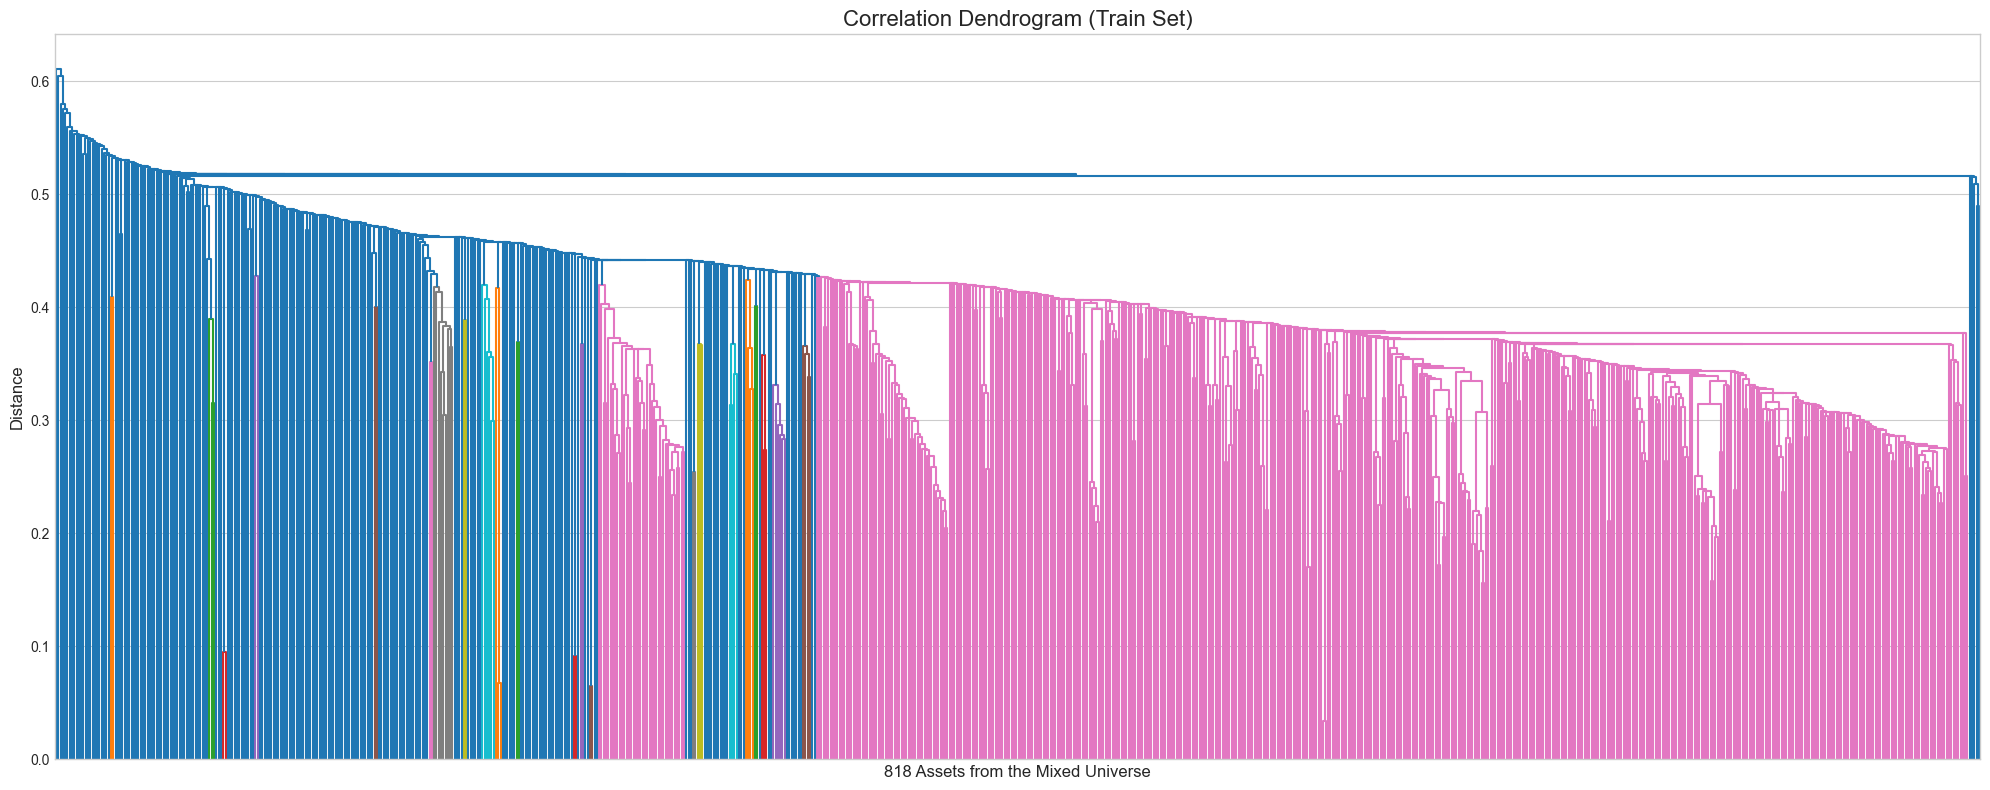

In [17]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
import numpy as np
import matplotlib.pyplot as plt

split_idx = int(len(df_returns) * 0.66) 

train_returns = df_returns.iloc[:split_idx]
test_returns = df_returns.iloc[split_idx:]

print(f"Train: {len(train_returns)} days")
print(f"Test: {len(test_returns)} days\n")

corr_matrix = train_returns.corr()
dist_matrix = np.sqrt(np.clip(0.5 * (1 - corr_matrix), 0, 1))
condensed_dist = squareform(dist_matrix, checks=False)

Z_hrp = sch.linkage(condensed_dist, method='single')

plt.figure(figsize=(20, 8))
plt.title("Correlation Dendrogram (Train Set)", fontsize=16)

dendrogram_hrp = sch.dendrogram(
    Z_hrp,
    no_labels=True, 
    leaf_rotation=90
)

plt.xlabel("818 Assets from the Mixed Universe", fontsize=12)
plt.ylabel("Distance", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Recursive Bisection and Portfolio Weighting

With the hierarchical structure defined, we implement the **Hierarchical Risk Parity (HRP)** allocation logic.

The algorithm follows two main phases:
1. **Quasi-Diagonalization:** We reorganize the covariance matrix based on the leaf order of our dendrogram so that correlated assets are adjacent.
2. **Recursive Bisection:** Starting from the top of the tree, we split each cluster into two sub-clusters. We calculate the variance of each branch and allocate more weight to the lower-variance branch using an inverse-variance weighting factor ($\alpha$). This process continues until each individual asset is assigned a final weight.

> **Key Insight:** This dendrogram represents the identityof our portfolio's risk. Assets clustered closely together at the bottom of the tree are highly redundant from a diversification standpoint. The **Hierarchical Risk Parity (HRP)** algorithm will use this specific tree structure to distribute weights, ensuring that no single branch of correlated assets dominates the total risk of the portfolio.

In [18]:
cov_matrix = train_returns.cov() * 252

sort_ix = sch.leaves_list(Z_hrp)
sorted_tickers = cov_matrix.index[sort_ix].tolist()

def get_cluster_var(cov, c_items):
    """Compute cluster variance using inverse-risk parity"""
    cov_slice = cov.iloc[c_items, c_items]
    ivp = 1.0 / np.diag(cov_slice)
    ivp /= ivp.sum()
    c_var = np.dot(np.dot(ivp, cov_slice), ivp)
    return c_var

def get_hrp_weights(cov, sort_ix):
    """Distribute weights top-down based on branch variance"""
    w = pd.Series(1.0, index=sort_ix)
    c_items = [list(range(len(sort_ix)))]
    
    while len(c_items) > 0:
        c_items = [i[j:k] for i in c_items for j, k in ((0, len(i)//2), (len(i)//2, len(i))) if len(i) > 1]
        
        for i in range(0, len(c_items), 2):
            c_items0 = c_items[i]  
            c_items1 = c_items[i+1] 

            c_var0 = get_cluster_var(cov, c_items0)
            c_var1 = get_cluster_var(cov, c_items1)
            
            alpha = 1 - c_var0 / (c_var0 + c_var1)
            
            w.iloc[c_items0] *= alpha
            w.iloc[c_items1] *= (1 - alpha)
            
    return w

hrp_weights = get_hrp_weights(cov_matrix, sort_ix)

hrp_weights.index = cov_matrix.index[sort_ix]
hrp_weights = hrp_weights.sort_values(ascending=False)

print("\n Top 15 HRP Portfolio Weights ")
display((hrp_weights.head(15) * 100).round(2).astype(str) + ' %')

print(f"\nTotal portfolio weight: {hrp_weights.sum() * 100:.2f}%")


 Top 15 HRP Portfolio Weights 


MLM     1.14 %
LHX     0.43 %
MNST    0.39 %
ATI     0.38 %
WT      0.38 %
RTX     0.37 %
VRRM    0.36 %
COR     0.34 %
AM      0.34 %
OGN     0.33 %
CLH     0.32 %
OHI     0.32 %
CENT    0.31 %
EEFT    0.31 %
STZ     0.31 %
dtype: object


Total portfolio weight: 100.00%


>The Top 15 holdings demonstrate the algorithm's power to diversify. By assigning weights as low as 0.3% to 1.1% across 818 assets, the HRP ensures that the portfolio is not dependent on a single sector or stock. This risk-splitting approach creates a highly resilient portfolio structure, specifically designed to protect capital in the insurance-linked investment context.

## 8. Out-of-Sample Performance Evaluation

We perform a backtest on the data from 2024.

We compare our HRP Portfolio against a benchmark: the S&P 1500 Equal-Weight (EW) Portfolio. 
* **Equal-Weight:** A naive diversification strategy where $1/N$ of the capital is invested in every stock.
* **Sharpe Ratio:** Our primary KPI, measuring the excess return per unit of volatility.


Sharpe Ratio Comparison
HRP Portfolio          : 1.30
S&P 1500 Equal-Weight  : 0.94


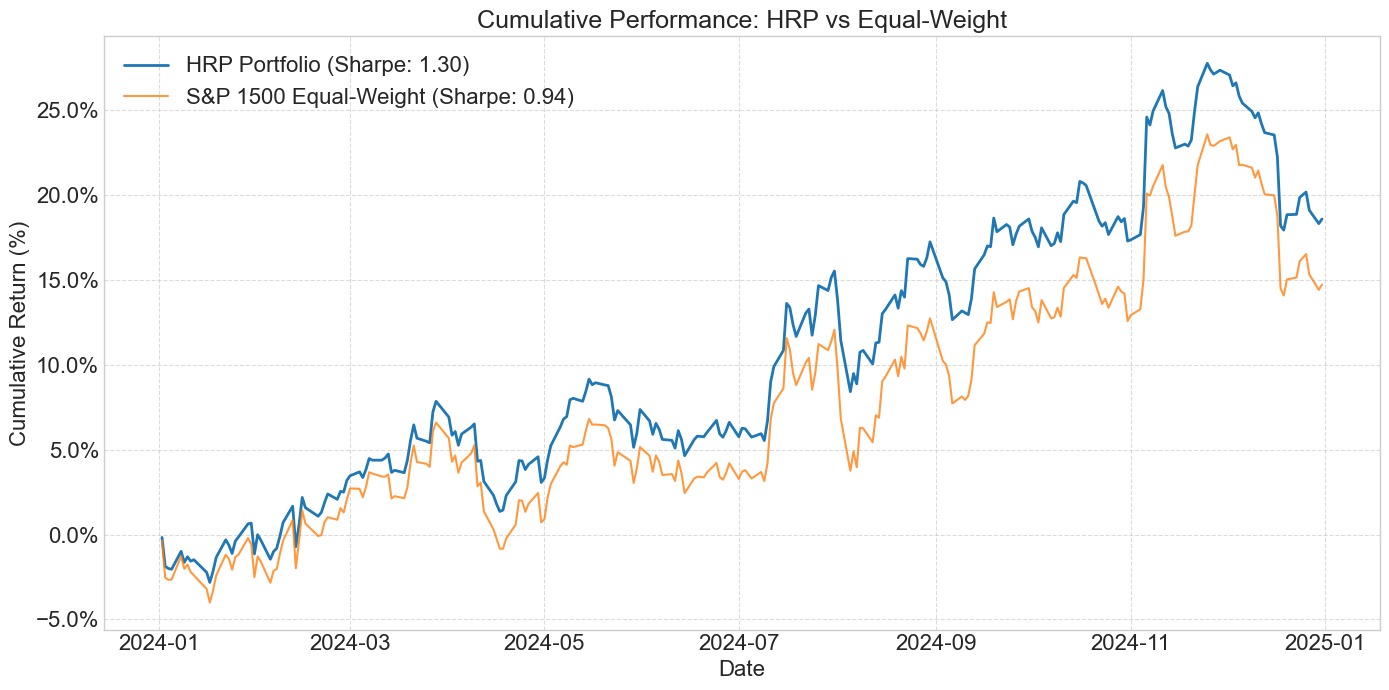

In [21]:
hrp_portfolio_returns_oos = (test_returns * hrp_weights).sum(axis=1).loc['2024-01-01':]

ew_portfolio_returns_oos = df_prices.pct_change().loc[test_returns.index].mean(axis=1).loc['2024-01-01':]


hrp_cum_returns_oos = (1 + hrp_portfolio_returns_oos).cumprod() - 1
ew_cum_returns_oos = (1 + ew_portfolio_returns_oos).cumprod() - 1

hrp_sharpe_oos = (hrp_portfolio_returns_oos.mean() / hrp_portfolio_returns_oos.std()) * np.sqrt(252)
ew_sharpe_oos = (ew_portfolio_returns_oos.mean() / ew_portfolio_returns_oos.std()) * np.sqrt(252)

print("\nSharpe Ratio Comparison")
print(f"HRP Portfolio          : {hrp_sharpe_oos:.2f}")
print(f"S&P 1500 Equal-Weight  : {ew_sharpe_oos:.2f}")

import matplotlib.ticker as mtick
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.plot(hrp_cum_returns_oos * 100, label=f'HRP Portfolio (Sharpe: {hrp_sharpe_oos:.2f})', color='#1f77b4', linewidth=2)
plt.plot(ew_cum_returns_oos * 100, label=f'S&P 1500 Equal-Weight (Sharpe: {ew_sharpe_oos:.2f})', color='#ff7f0e', alpha=0.8)

plt.title("Cumulative Performance: HRP vs Equal-Weight", fontsize=18)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Cumulative Return (%)", fontsize=16)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


> *  The HRP Portfolio achieved a **Sharpe Ratio of 1.30**, outperforming the Equal-Weight benchmark (0.94).
> *  The higher Sharpe Ratio confirms that the hierarchical allocation effectively minimized volatility without sacrificing the growth potential required by the mandate.
> *  The model successfully managed an 818-asset universe, providing a diversified, defensive, and mathematically sound core for the life insurance fund.

In [22]:

hrp_vol_oos = hrp_portfolio_returns_oos.std() * np.sqrt(252)
ew_vol_oos = ew_portfolio_returns_oos.std() * np.sqrt(252)

hrp_wealth = 1 + hrp_cum_returns_oos
hrp_peaks = hrp_wealth.cummax()
hrp_drawdown = (hrp_wealth - hrp_peaks) / hrp_peaks
hrp_max_dd = hrp_drawdown.min()


ew_wealth = 1 + ew_cum_returns_oos
ew_peaks = ew_wealth.cummax()
ew_drawdown = (ew_wealth - ew_peaks) / ew_peaks
ew_max_dd = ew_drawdown.min()

print("--- Risk Metrics (2024 Test) ---")
print(f"Annualized Volatility (HRP) : {hrp_vol_oos * 100:.2f}%")
print(f"Annualized Volatility (EW)  : {ew_vol_oos * 100:.2f}%")
print("-" * 40)
print(f"Maximum Drawdown (HRP)      : {hrp_max_dd * 100:.2f}%")
print(f"Maximum Drawdown (EW)       : {ew_max_dd * 100:.2f}%")

--- Risk Metrics (2024 Test) ---
Annualized Volatility (HRP) : 13.91%
Annualized Volatility (EW)  : 15.88%
----------------------------------------
Maximum Drawdown (HRP)      : -7.69%
Maximum Drawdown (EW)       : -7.68%
